In [ ]:
# imports
import os
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2

from PIL import Image

In [2]:
# reference training images folder:
train_images_folder = "Data/Training/Training_Images"

# reference csv:
train_csv = "Data/Training/Training_LabelsDemographic.csv"
# load in csv:
train_df = pd.read_csv(train_csv)

# csv columns: 'image', 'myopic_maculopathy_grade', 'age', 'sex', 'height', 'weight', 'data_center'
print("train_csv columns: ", train_df.columns)

# head
print("train_df head: ")
print(train_df.head())

train_csv columns:  Index(['image', 'myopic_maculopathy_grade', 'age', 'sex', 'height', 'weight',
       'data_center'],
      dtype='str')
train_df head: 
                        image  myopic_maculopathy_grade  age   sex  height  \
0  mmac_task_1_train_0001.png                         0   51  male   183.5   
1  mmac_task_1_train_0002.png                         0   51  male   183.5   
2  mmac_task_1_train_0003.png                         0   50  male   184.5   
3  mmac_task_1_train_0004.png                         0   50  male   184.5   
4  mmac_task_1_train_0005.png                         0   49  male   184.5   

   weight  data_center  
0    78.9            1  
1    78.9            1  
2    81.7            1  
3    81.7            1  
4    82.2            1  


In [3]:
# show values in myopic_maculopathy_grade
print("myopic_maculopathy_grade values: ", train_df["myopic_maculopathy_grade"].unique())
# grade 0 to 4

myopic_maculopathy_grade values:  [0 1 2 3 4]


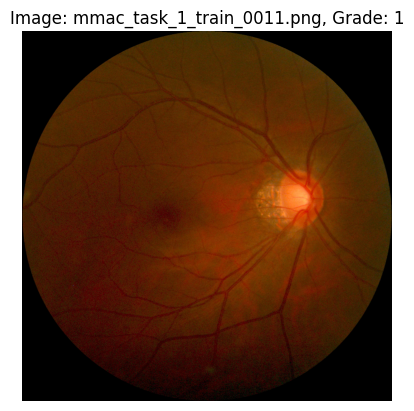

Image shape:  (800, 800)
Min pixel value:  (0, 0, 0)
Max pixel value:  (255, 176, 83)


/var/folders/q3/f8bspqwx7l54y8mwlwq7gq240000gn/T/ipykernel_58055/2857640624.py:12: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  print("Min pixel value: ", min(image.getdata()))
/var/folders/q3/f8bspqwx7l54y8mwlwq7gq240000gn/T/ipykernel_58055/2857640624.py:13: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  print("Max pixel value: ", max(image.getdata()))


In [4]:
# load an image and show it
image_path = os.path.join(train_images_folder, train_df["image"][10])

image = Image.open(image_path).convert("RGB") # matplotlib expects RGB, PIL loads RGBA, so we need to convert it first
plt.imshow(image)
plt.title(f"Image: {train_df['image'][10]}, Grade: {train_df['myopic_maculopathy_grade'][10]}")
plt.axis("off")
plt.show()

# print image shape and values:
print("Image shape: ", image.size)
print("Min pixel value: ", min(image.getdata()))
print("Max pixel value: ", max(image.getdata()))

In [5]:
# get all images keys of grade 0:
grade_0_images = train_df[train_df["myopic_maculopathy_grade"] == 0]["image"].tolist()
grade_1_images = train_df[train_df["myopic_maculopathy_grade"] == 1]["image"].tolist()
grade_2_images = train_df[train_df["myopic_maculopathy_grade"] == 2]["image"].tolist()
grade_3_images = train_df[train_df["myopic_maculopathy_grade"] == 3]["image"].tolist()
grade_4_images = train_df[train_df["myopic_maculopathy_grade"] == 4]["image"].tolist()

In [6]:
# function to loop through all images in a grade,
# load them, convert to grayscale, and show histogram of pixel values:

# use tqdm to show progress bar:
def show_histogram_of_grade(grade_images, grade, bins=256, resize_to=(256,256)):
    import numpy as np
    agg = np.zeros(256, dtype=np.int64)
    for image_name in tqdm(grade_images, desc=f"Processing grade {grade}"):
        image_path = os.path.join(train_images_folder, image_name)
        with Image.open(image_path).convert("L") as im:
            if resize_to:
                im = im.resize(resize_to)
            arr = np.asarray(im)
            agg += np.bincount(arr.ravel(), minlength=256)

    # normalise the histogram by the total number of pixels:
    agg = agg / (len(grade_images) * resize_to[0] * resize_to[1])

    # discard bins below 10 as these are background pixels:
    agg[:10] = 0

    edges = np.linspace(0, 256, bins+1, dtype=int) # 256 bins from 0 to 255
    counts = np.add.reduceat(agg, edges[:-1]) # sum counts in each bin
    centers = (edges[:-1] + edges[1:]) / 2
    plt.bar(centers, counts, width=(edges[1]-edges[0]))
    plt.title(f"Histogram of pixel values for grade {grade}")
    plt.xlabel("Pixel value")
    plt.ylabel("Frequency")
    plt.show()

    # print the modal bin:
    modal_bin = centers[np.argmax(counts)]
    print(f"Modal pixel value for grade {grade}: {modal_bin}")

Processing grade 0: 100%|██████████| 404/404 [00:02<00:00, 135.37it/s]


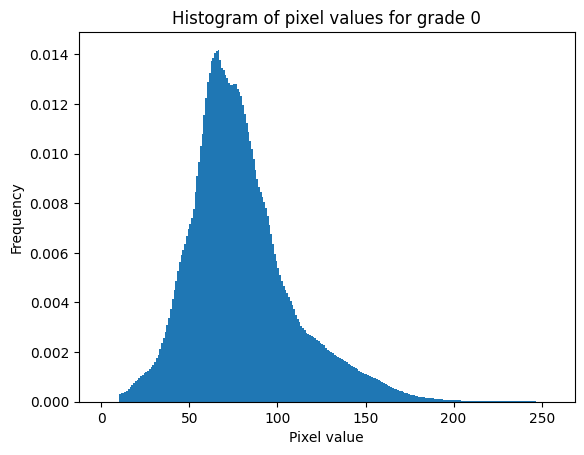

Modal pixel value for grade 0: 66.5


Processing grade 1: 100%|██████████| 412/412 [00:03<00:00, 134.99it/s]


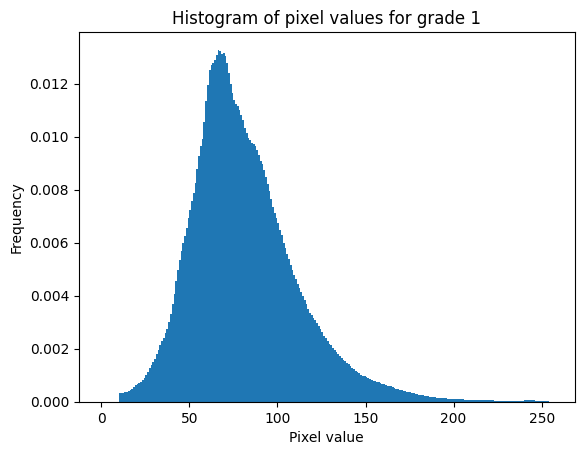

Modal pixel value for grade 1: 66.5


Processing grade 2: 100%|██████████| 224/224 [00:01<00:00, 135.32it/s]


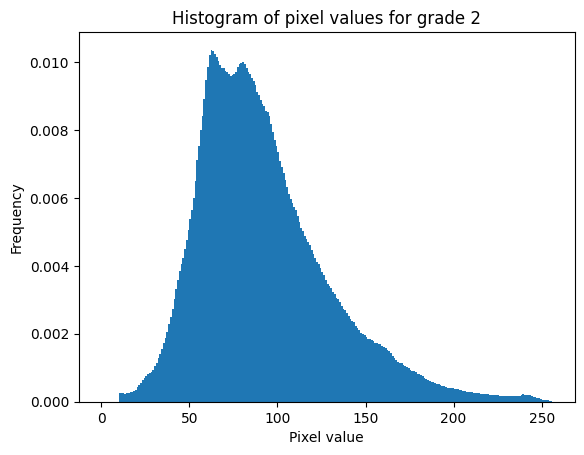

Modal pixel value for grade 2: 62.5


Processing grade 3: 100%|██████████| 60/60 [00:00<00:00, 134.74it/s]


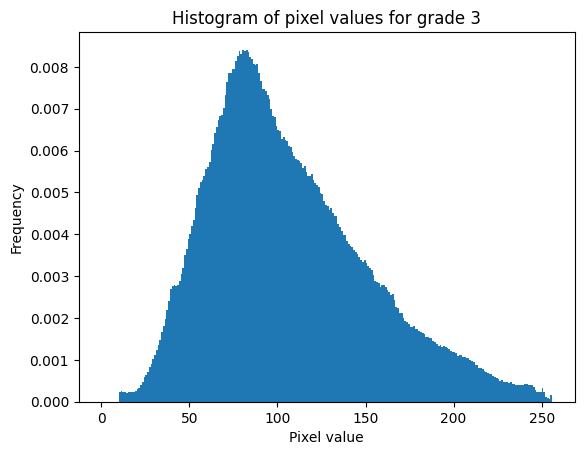

Modal pixel value for grade 3: 80.5


Processing grade 4: 100%|██████████| 43/43 [00:00<00:00, 126.52it/s]


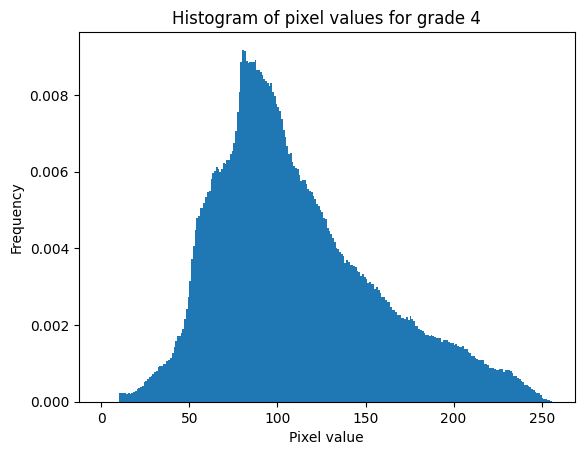

Modal pixel value for grade 4: 80.5


In [7]:
# show histogram of pixel values for each grade:
for grade, grade_images in enumerate([grade_0_images, grade_1_images, grade_2_images, grade_3_images, grade_4_images]):
    show_histogram_of_grade(grade_images, grade)

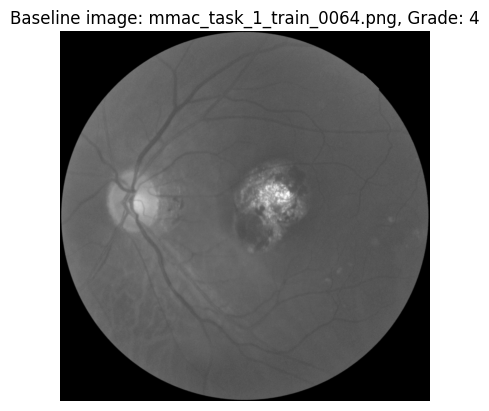

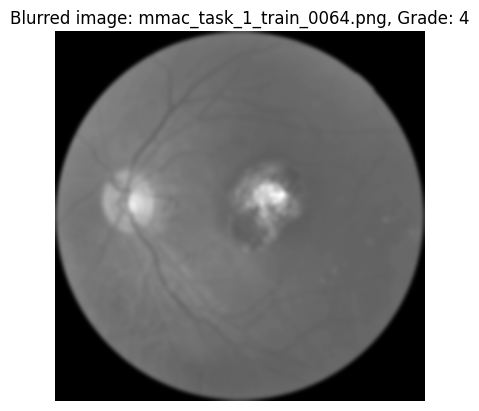

Min pixel value:  0
Max pixel value:  255


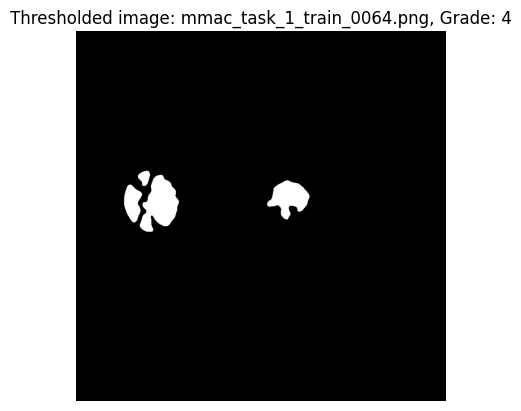

In [60]:
# load an image an image and convert to grayscale as before, resize to 256x256 and show it:
idx = 63
#idx = 143

image_path = os.path.join(train_images_folder, train_df["image"][idx])

image_cv = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
# show baseline image
plt.imshow(image_cv, cmap="gray")
plt.title(f"Baseline image: {train_df['image'][idx]}, Grade: {train_df['myopic_maculopathy_grade'][idx]}")
plt.axis("off")
plt.show()

# blur the image and show again:
image_cv = cv2.GaussianBlur(image_cv, (25, 25), 0)
plt.imshow(image_cv, cmap="gray")
plt.title(f"Blurred image: {train_df['image'][idx]}, Grade: {train_df['myopic_maculopathy_grade'][idx]}")
plt.axis("off")
plt.show()

_, thresh = cv2.threshold(image_cv, 120, 255, cv2.THRESH_BINARY)

# print value range:
print("Min pixel value: ", thresh.min())
print("Max pixel value: ", thresh.max())

plt.imshow(thresh, cmap="gray")
plt.title(f"Thresholded image: {train_df['image'][idx]}, Grade: {train_df['myopic_maculopathy_grade'][idx]}")
plt.axis("off")
plt.show()